In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch

# 1. Load the main TSV dataset (no skiprows based on the diagnostic)
cols = ['idx', 'par_id', 'keyword', 'country', 'text', 'label']
df = pd.read_csv('dontpatronizeme_pcl.tsv', sep='\t', names=cols)

# Clean up string formatting
df['idx'] = df['idx'].astype(str).str.strip()
df = df.dropna(subset=['text', 'label'])
df['label'] = pd.to_numeric(df['label'], errors='coerce')

# Binarize labels: 0, 1 -> 0 (Negative) | 2, 3, 4 -> 1 (Positive)
df['binary_label'] = df['label'].apply(lambda x: 1 if x >= 2 else 0)

# 2. Load splits
train_ids = pd.read_csv('train_semeval_parids-labels.csv')
dev_ids = pd.read_csv('dev_semeval_parids-labels.csv')

# The diagnostic proved the split files use 'idx', not 'par_id'
train_ids['par_id'] = train_ids['par_id'].astype(str).str.strip()
dev_ids['par_id'] = dev_ids['par_id'].astype(str).str.strip()

# 3. Create Train and Dev DataFrames by matching 'idx' to the split files
train_df = df[df['idx'].isin(train_ids['par_id'])].copy()
dev_df = df[df['idx'].isin(dev_ids['par_id'])].copy()

print(f"Train size: {len(train_df)} | Dev size: {len(dev_df)}")

Train size: 8375 | Dev size: 2093


In [ ]:
import pandas as pd

# 1. Load without skipping rows
cols = ['idx', 'par_id', 'keyword', 'country', 'text', 'label']
df = pd.read_csv('dontpatronizeme_pcl.tsv', sep='\t', names=cols)

# 2. Aggressively clean the strings (remove @@ and strip all whitespace)
df['par_id'] = df['par_id'].astype(str).str.replace('@@', '', regex=False).str.strip()
df['idx'] = df['idx'].astype(str).str.strip()

# 3. Load and clean the CSV IDs
train_ids = pd.read_csv('train_semeval_parids-labels.csv')
train_ids['par_id'] = train_ids['par_id'].astype(str).str.strip()

# 4. Diagnostic Prints
print("--- Diagnostic Check ---")
print(f"Total rows in TSV: {len(df)}")
print(f"Total IDs in train_ids: {len(train_ids)}")
print(f"First 5 TSV par_ids: {df['par_id'].head().tolist()}")
print(f"First 5 Train CSV par_ids: {train_ids['par_id'].head().tolist()}")

# 5. Test merging on par_id
train_df_par = df[df['par_id'].isin(train_ids['par_id'])]
print(f"\nMatches using 'par_id': {len(train_df_par)}")

# 6. Test merging on idx
train_df_idx = df[df['idx'].isin(train_ids['par_id'])]
print(f"Matches using 'idx' instead: {len(train_df_idx)}")

--- Diagnostic Check ---
Total rows in TSV: 10472
Total IDs in train_ids: 8375
First 5 TSV par_ids: ['nan', 'nan', 'nan', '24942188', '21968160']
First 5 Train CSV par_ids: ['4341', '4136', '10352', '8279', '1164']

Matches using 'par_id': 1
Matches using 'idx' instead: 8375


# Exercise 2 Exploratory Data Analysis

Found 0 duplicate text entries in train set.


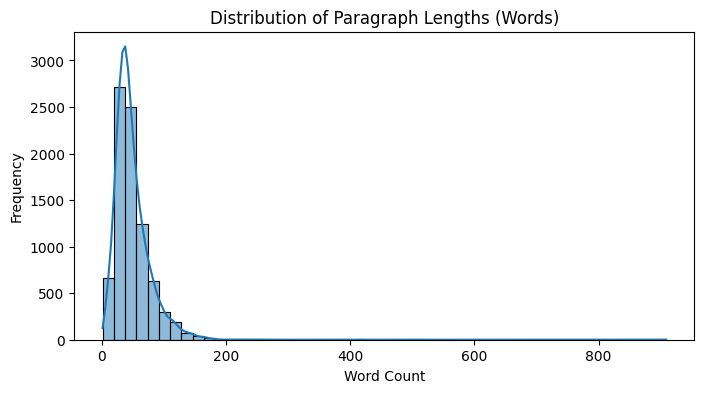

Max word count: 909
99th percentile word count: 142.0


/var/folders/l7/h15d3n8j2dq3nvmv6kg65qyc0000gn/T/ipykernel_7512/2915446233.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='binary_label', data=train_df, palette='viridis')


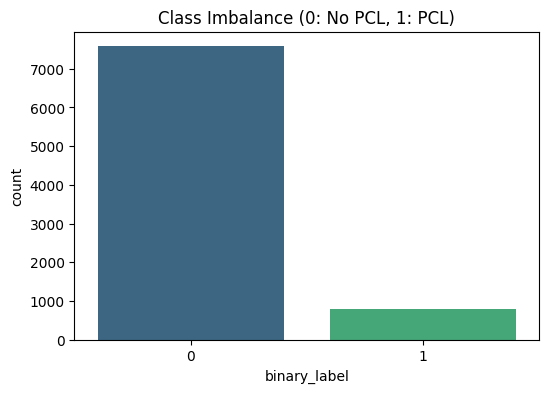

Positive Class (PCL): 9.48% of the training data.


In [6]:
# ==========================================
# Technique 1: Data Quality & Structural Profiling (Duplicates & Outliers)
# ==========================================
# Check for duplicates (Data Leakage prevention)
duplicates = train_df.duplicated(subset=['text']).sum()
print(f"Found {duplicates} duplicate text entries in train set.")

# Check sequence lengths (Outlier detection)
train_df['text_length'] = train_df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 4))
sns.histplot(train_df['text_length'], bins=50, kde=True)
plt.title('Distribution of Paragraph Lengths (Words)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

print(f"Max word count: {train_df['text_length'].max()}")
print(f"99th percentile word count: {np.percentile(train_df['text_length'], 99)}")

# ==========================================
# Technique 2: Label Distribution & Imbalance
# ==========================================
plt.figure(figsize=(6, 4))
sns.countplot(x='binary_label', data=train_df, palette='viridis')
plt.title('Class Imbalance (0: No PCL, 1: PCL)')
plt.show()

pos_ratio = train_df['binary_label'].mean() * 100
print(f"Positive Class (PCL): {pos_ratio:.2f}% of the training data.")

# Clean the data based on findings
train_df = train_df.drop_duplicates(subset=['text'])

In [7]:
model_name = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Using 256 as max_length based on EDA 99th percentile (adjust if your EDA shows differently)
MAX_LEN = 256 

class PCLDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.labels)

train_encodings = tokenizer(train_df['text'].tolist(), truncation=True, padding=True, max_length=MAX_LEN)
dev_encodings = tokenizer(dev_df['text'].tolist(), truncation=True, padding=True, max_length=MAX_LEN)

train_dataset = PCLDataset(train_encodings, train_df['binary_label'].tolist())
dev_dataset = PCLDataset(dev_encodings, dev_df['binary_label'].tolist())

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
/Users/aadeesh/miniconda3/envs/redditEnv/lib/python3.9/site-packages/transformers/convert_slow_tokenizer.py:454: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
